In [8]:
# Instalação das bibliotecas necessárias
!pip install scikit-learn pandas google-generativeai
!pip install -U google-generativeai

In [9]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import google.generativeai as genai



In [10]:
# =====================================================================
# PARTE 1: Geração de Dados Realistas (ETL Simulado)
# =====================================================================
np.random.seed(42) # Mantém os valores consistentes a cada execução

n_amostras = 1000

# 1. Gerando dados de AGVs Saudáveis (70% da frota)
# Temperaturas em torno de 80°C, baterias variadas, vibração baixa (~2.5Hz)
n_saudaveis = int(n_amostras * 0.7)
temp_saudavel = np.random.normal(loc=80, scale=5, size=n_saudaveis)
bat_saudavel = np.random.uniform(low=40, high=100, size=n_saudaveis)
vib_saudavel = np.random.normal(loc=2.5, scale=0.5, size=n_saudaveis)
status_saudavel = np.zeros(n_saudaveis) # 0 = Saudável

# 2. Gerando dados de AGVs com Falha (30% da frota)
# Temperaturas altas (~110°C), baterias mais baixas, vibração alta (~6.5Hz)
n_falhas = n_amostras - n_saudaveis
temp_falha = np.random.normal(loc=110, scale=8, size=n_falhas)
bat_falha = np.random.uniform(low=5, high=50, size=n_falhas)
vib_falha = np.random.normal(loc=6.5, scale=1.2, size=n_falhas)
status_falha = np.ones(n_falhas) # 1 = Falha Crítica

# 3. Consolidando no DataFrame e embaralhando
df_agv = pd.DataFrame({
    'Temperatura_Motor': np.concatenate([temp_saudavel, temp_falha]),
    'Nivel_Bateria': np.concatenate([bat_saudavel, bat_falha]),
    'Vibracao_Chassi': np.concatenate([vib_saudavel, vib_falha]),
    'Status_Falha': np.concatenate([status_saudavel, status_falha])
})
df_agv = df_agv.sample(frac=1, random_state=42).reset_index(drop=True)

print("--- Amostra do Dataset Gerado ---")
print(df_agv.head(), "\n")



--- Amostra do Dataset Gerado ---
   Temperatura_Motor  Nivel_Bateria  Vibracao_Chassi  Status_Falha
0          82.716801      97.108707         2.775743           0.0
1         114.104683      15.175640         5.388343           1.0
2         104.868147      15.368750         5.999160           1.0
3          77.131690      80.052994         1.903037           0.0
4          74.376790      83.895371         3.069939           0.0 



In [11]:
# =====================================================================
# PARTE 2: Treinamento da Árvore de Decisão
# =====================================================================
X = df_agv[['Temperatura_Motor', 'Nivel_Bateria', 'Vibracao_Chassi']]
y = df_agv['Status_Falha']

# Separando em dados de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_agv = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_agv.fit(X_train, y_train)

# Avaliando o modelo
acuracia = accuracy_score(y_test, modelo_agv.predict(X_test))
print(f"--- Performance do Modelo ---")
print(f"Acurácia da Árvore de Decisão: {acuracia * 100:.2f}%\n")

# Simulando um AGV com problemas para passar para o Gemini
nova_leitura = pd.DataFrame({
    'Temperatura_Motor': [108.5],
    'Nivel_Bateria': [22.0],
    'Vibracao_Chassi': [5.8]
})

previsao = modelo_agv.predict(nova_leitura)[0]
diagnostico_tecnico = "Alerta: Falha Crítica Iminente" if previsao == 1 else "Operação Saudável"

print(f"--- Diagnóstico Operacional ---")
print(f"Leitura -> Temp: {nova_leitura['Temperatura_Motor'][0]}°C | Bat: {nova_leitura['Nivel_Bateria'][0]}% | Vib: {nova_leitura['Vibracao_Chassi'][0]}Hz")
print(f"Decisão: {diagnostico_tecnico}\n")



--- Performance do Modelo ---
Acurácia da Árvore de Decisão: 99.50%

--- Diagnóstico Operacional ---
Leitura -> Temp: 108.5°C | Bat: 22.0% | Vib: 5.8Hz
Decisão: Alerta: Falha Crítica Iminente



In [12]:
# =====================================================================
# PARTE 3: Integração com IA Generativa (Gemini)
# =====================================================================
from google.colab import userdata
import google.generativeai as genai

# Tratamento de erro caso a chave de API não seja encontrada
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    model = genai.GenerativeModel('gemini-2.5-flash')
except Exception as e:
    print("⚠️ Erro de configuração da API. Verifique se a 'GOOGLE_API_KEY' está salva no Colab.")
    print(f"Detalhe: {e}")

prompt = f"""
Você é a inteligência co-piloto do projeto SmartLog. Nosso sistema especialista (Árvore de Decisão)
analisou a telemetria de um AGV logístico em rota e gerou o seguinte diagnóstico:

[DADOS DA TELEMETRIA]
- Temperatura do Motor: {nova_leitura['Temperatura_Motor'][0]:.1f}°C
- Nível de Bateria Atual: {nova_leitura['Nivel_Bateria'][0]:.1f}%
- Frequência de Vibração do Chassi: {nova_leitura['Vibracao_Chassi'][0]:.1f}Hz

[DIAGNÓSTICO DO SISTEMA]
- Status: {diagnostico_tecnico}

Gere um relatório operacional conciso (máximo de 2 parágrafos e alguns bullet points) contendo:
1. Uma explicação técnica de como esses três sensores indicam o estado mecânico/elétrico do AGV.
2. Duas ações corretivas imediatas para a central de controle.
"""

print(f"--- Relatório Interpretativo (Gemini Co-Piloto) ---")

# Tratamento de exceção na chamada da API
try:
    resposta_interpretativa = model.generate_content(prompt)
    print(resposta_interpretativa.text)
except Exception as e:
    print("⚠️ Falha na comunicação com a API do Gemini. Protocolo de contingência ativado.")
    print(f"Detalhe técnico: {e}")
    print("\n[MENSAGEM AUTOMÁTICA DE CONTINGÊNCIA]")
    print(f"Alerta do Sistema Especialista: {diagnostico_tecnico}")
    print("Ação recomendada: O operador deve verificar os dados de telemetria manualmente no painel de controle.")

--- Relatório Interpretativo (Gemini Co-Piloto) ---
Entendido, co-piloto. Com base nos dados de telemetria e no diagnóstico, aqui está o relatório operacional:

A telemetria indica uma situação de grave alerta para o AGV. A **Temperatura do Motor** em 108.5°C é extremamente elevada, sugerindo sobrecarga severa, atrito excessivo em rolamentos ou componentes internos, ou até mesmo um problema elétrico grave que pode levar à falha total do motor e potenciais riscos de segurança. Complementarmente, a **Frequência de Vibração do Chassi** de 5.8Hz aponta para um problema mecânico significativo de baixa frequência, como desbalanceamento de rodas, falha em um eixo, rolamentos estruturais comprometidos ou montagens soltas, o que contribui para o esforço do motor e instabilidade. O **Nível de Bateria Atual** de 22.0% adiciona uma camada de urgência, indicando baixa autonomia e a impossibilidade do AGV de retornar à base de carga ou operar por mais tempo sob tais condições de estresse. Juntos, es

In [13]:
# =====================================================================
# PARTE 4: Implementação da Inteligência Evolutiva (RNA - TensorFlow/Keras)
# =====================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("--- Iniciando o Treinamento da Rede Neural Preditiva ---")

# 1. Arquitetura da Rede Neural
# Camada de entrada (3 features: Temp, Bat, Vib), camadas ocultas para aprender padrões complexos e saída Sigmoid (Probabilidade 0 a 1)
modelo_rna = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Compilação do modelo (Otimizador Adam para ajuste dinâmico dos pesos)
modelo_rna.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Treinamento com histórico para avaliação de evolução
historico_rna = modelo_rna.fit(
    X_train, y_train,
    epochs=50,          # Número de ciclos de aprendizado
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0           # Oculta os logs de cada epoch para manter o output limpo
)

# Avaliação final
loss, accuracy = modelo_rna.evaluate(X_test, y_test, verbose=0)
print(f"Treinamento Concluído! Acurácia Final da RNA: {accuracy * 100:.2f}%")

--- Iniciando o Treinamento da Rede Neural Preditiva ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinamento Concluído! Acurácia Final da RNA: 99.50%


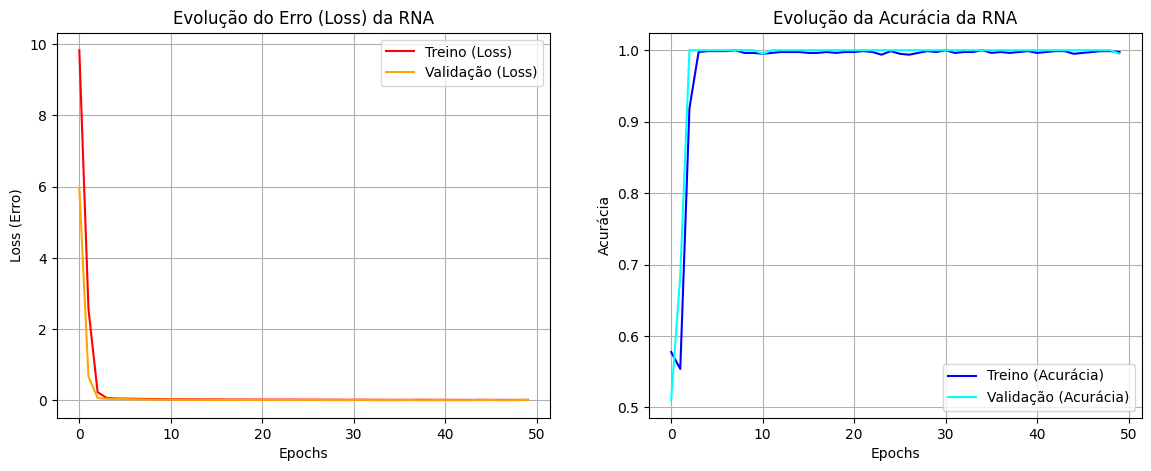

In [14]:
# =====================================================================
# PARTE 5: Gráficos de Evolução do Aprendizado (Loss e Accuracy)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolução da Perda (Loss) - Deve cair com o tempo
ax1.plot(historico_rna.history['loss'], label='Treino (Loss)', color='red')
ax1.plot(historico_rna.history['val_loss'], label='Validação (Loss)', color='orange')
ax1.set_title('Evolução do Erro (Loss) da RNA')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Erro)')
ax1.legend()
ax1.grid(True)

# Gráfico 2: Evolução da Acurácia (Fitness) - Deve subir com o tempo
ax2.plot(historico_rna.history['accuracy'], label='Treino (Acurácia)', color='blue')
ax2.plot(historico_rna.history['val_accuracy'], label='Validação (Acurácia)', color='cyan')
ax2.set_title('Evolução da Acurácia da RNA')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True)

plt.show()

In [15]:
# =====================================================================
# PARTE 6: Previsão Preditiva, Atuadores e Integração com LLM (Gemini)
# =====================================================================

try:
    # Simulando uma leitura que a Árvore de Decisão original considerou falha,
    # mas vamos ver a probabilidade exata da RNA.
    probabilidade_falha = modelo_rna.predict(nova_leitura, verbose=0)[0][0]

    print(f"\n--- Comparação de Modelos ---")
    print(f"Decisão da Árvore (Etapa 2): {diagnostico_tecnico}")
    print(f"Probabilidade RNA (Etapa 3): {probabilidade_falha * 100:.2f}% de chance de falha crítica.")

    # Lógica de Atuadores (Nova Lógica com RNA)
    acao_atuador = ""
    if probabilidade_falha > 0.85:
        acao_atuador = "ATUADOR ACIONADO: Desligamento emergencial do motor e freio travado."
    elif probabilidade_falha > 0.50:
        acao_atuador = "ATUADOR ACIONADO: Redução de velocidade em 50% e desvio de rota para manutenção."
    else:
        acao_atuador = "ATUADOR OCIOSO: Manter velocidade de cruzeiro."

    print(f"\nStatus do Atuador: {acao_atuador}\n")

    # Prompt atualizado para o Gemini focar na previsão
    prompt_evolutivo = f"""
    Atue como Analista Preditivo do SmartLog.
    Recebemos a seguinte telemetria de um AGV: Temperatura {nova_leitura['Temperatura_Motor'][0]:.1f}°C, Bateria {nova_leitura['Nivel_Bateria'][0]:.1f}%, Vibração {nova_leitura['Vibracao_Chassi'][0]:.1f}Hz.

    Nossa nova Rede Neural previu uma probabilidade de falha de {probabilidade_falha * 100:.2f}%.
    O sistema tomou a seguinte decisão: {acao_atuador}

    Escreva um relatório operacional de 1 parágrafo explicando:
    1. Como o modelo preditivo ajudou a evitar uma quebra (baseado nessa probabilidade).
    2. Se a ação do atuador foi adequada e por quê.
    """

    print("--- Relatório Preditivo (Gemini API) ---")

    # Tratamento de erro específico para a geração do relatório via LLM
    try:
        resposta_evolutiva = model.generate_content(prompt_evolutivo)
        print(resposta_evolutiva.text)
    except Exception as api_erro:
        print("⚠️ Erro na comunicação com a API do Gemini ao gerar o relatório final.")
        print(f"Detalhe: {api_erro}")
        print(f"\n[MENSAGEM PADRÃO DE CONTINGÊNCIA]")
        print(f"Ação do sistema mantida: {acao_atuador}")
        print("Relatório detalhado indisponível no momento. Equipe de manutenção notificada.")

except Exception as rna_erro:
    print("⚠️ Erro crítico na inferência da Rede Neural Artificial.")
    print(f"Detalhe: {rna_erro}")
    print("\n[AÇÃO AUTOMÁTICA DE SEGURANÇA]")
    print("Desligamento emergencial preventivo do AGV acionado devido à perda de comunicação com o módulo preditivo.")


--- Comparação de Modelos ---
Decisão da Árvore (Etapa 2): Alerta: Falha Crítica Iminente
Probabilidade RNA (Etapa 3): 100.00% de chance de falha crítica.

Status do Atuador: ATUADOR ACIONADO: Desligamento emergencial do motor e freio travado.

--- Relatório Preditivo (Gemini API) ---
O modelo preditivo do SmartLog, com sua nova Rede Neural, demonstrou ser fundamental ao prever uma probabilidade de falha de 100.00% no AGV com base na telemetria crítica de Temperatura (108.5°C) e Vibração (5.8Hz). Essa detecção precoce e inequívoca permitiu que o sistema agisse proativamente, evitando uma quebra catastrófica que resultaria em danos extensos ao AGV, interrupções operacionais significativas e potenciais riscos de segurança. A ação do atuador de desligamento emergencial do motor e freio travado foi absolutamente adequada e crucial, pois, diante de uma certeza de falha tão elevada, essa intervenção imediata transformou uma potencial falha descontrolada em uma parada gerenciada, minimizando